In [1]:
import os
import re
import json
import math
import random
import string
from dataclasses import dataclass
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ---------------------------
# 0) Colab drive mount
# ---------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print("Not running in Colab (drive mount skipped):", e)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ---------------------------
# 1) Paths
# ---------------------------
DATA_DIR = "/content/drive/MyDrive/TASK01/data/"
TRAIN_CSV = os.path.join(DATA_DIR, "train_with_balanced_dupes_gaps.csv")
DEV_CSV   = os.path.join(DATA_DIR, "dev_with_balanced_dupes_gaps.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test_with_balanced_dupes_gaps.csv")

In [12]:
MODEL_DIR = "/content/drive/MyDrive/TASK01/models/final_task1a_text_custom_transformer_MOD_1"
#os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

seed_everything(SEED)


In [5]:
# ---------------------------
# 2) Load data + label mapping sanity checks
# ---------------------------
train_df = pd.read_csv(TRAIN_CSV)
dev_df   = pd.read_csv(DEV_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("Train size:", len(train_df))
print("Dev size  :", len(dev_df))
print("Test size :", len(test_df))
print("Columns:", list(train_df.columns))

assert ("tweet_text" in train_df.columns), "Expected tweet_text column in CSVs"
assert "label_text" in train_df.columns, "Expected label_text column"

print("\nUnique labels (raw):")
print("train:", train_df["label_text"].unique())
print("dev  :", dev_df["label_text"].unique())
print("test :", test_df["label_text"].unique())

LABEL_MAP = {
    "non-informative": 0,
    "not_informative": 0,
    "non informative": 0,
    "not informative": 0,
    "informative": 1
}

def map_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["label_text_norm"] = df["label_text"].astype(str).str.strip().str.lower()
    df["label_text_id"] = df["label_text_norm"].map(LABEL_MAP)
    return df

train_df = map_labels(train_df)
dev_df   = map_labels(dev_df)
test_df  = map_labels(test_df)

print("\nNull label_text_id counts:")
print("train:", int(train_df["label_text_id"].isnull().sum()))
print("dev  :", int(dev_df["label_text_id"].isnull().sum()))
print("test :", int(test_df["label_text_id"].isnull().sum()))
if train_df["label_text_id"].isnull().sum() > 0:
    print("\nUnmapped labels in TRAIN:")
    print(train_df.loc[train_df["label_text_id"].isnull(), "label_text"].value_counts().head(20))
    raise ValueError("Some labels could not be mapped. Fix LABEL_MAP.")

print("\nLabel distribution (train/dev/test):")
print(train_df["label_text_id"].value_counts())
print(dev_df["label_text_id"].value_counts())
print(test_df["label_text_id"].value_counts())

Train size: 6927
Dev size  : 1312
Test size : 1312
Columns: ['event_name', 'tweet_id', 'image_id', 'tweet_text', 'image', 'label', 'label_text', 'label_image', 'label_text_image']

Unique labels (raw):
train: ['not_informative' 'informative']
dev  : ['not_informative' 'informative']
test : ['not_informative' 'informative']

Null label_text_id counts:
train: 0
dev  : 0
test : 0

Label distribution (train/dev/test):
label_text_id
1    3628
0    3299
Name: count, dtype: int64
label_text_id
1    687
0    625
Name: count, dtype: int64
label_text_id
1    687
0    625
Name: count, dtype: int64


In [6]:
# ---------------------------
# 3) Preprocessing (tweet-robust, transformer-friendly)
# ---------------------------
# Dependencies: emoji, contractions, ftfy
try:
    import emoji as emoji_lib
    import contractions
except Exception:
    !pip -q install emoji contractions
    import emoji as emoji_lib
    import contractions

try:
    import ftfy
except Exception:
    !pip -q install ftfy
    import ftfy

import html


In [7]:
def preprocess_text(text: str) -> str:
    text = str(text)

    # Fix mojibake / bad encodings (e.g., didnâ€™t)
    text = ftfy.fix_text(text)

    # Decode HTML entities (&amp; -> &)
    text = html.unescape(text)

    # Lowercase
    text = text.lower()

    # Replace URLs with token (can help precision/recall)
    text = re.sub(r"(http|https)://\S+|www\.\S+", " <URL> ", text)

    # Remove RT markers
    text = re.sub(r"\brt\b\s*:?\s*", " ", text)

    # Replace @mentions
    text = re.sub(r"@\w+", " <USER> ", text)

    # Keep hashtag word, remove only '#'
    text = text.replace("#", "")

    # Emojis -> text (":fire:" etc.)
    text = emoji_lib.demojize(text)

    # Expand contractions (can't -> cannot)
    text = contractions.fix(text)

    # Normalize numbers
    text = re.sub(r"\b\d+(\.\d+)?\b", " <NUM> ", text)

    # Normalize elongated characters (soooo -> soo)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Punctuation -> space, keep ! and ? as tokens
    punct = string.punctuation.replace("!", "").replace("?", "")
    text = re.sub(f"[{re.escape(punct)}]", " ", text)

    # Tokenize (no NLTK)
    tokens = re.findall(r"<url>|<user>|<num>|[a-z_]+|[!?]", text)

    # Remove short junk (keep negations and a few meaningful short tokens)
    keep_short = {"no", "not", "ok", "us", "im", "we", "i"}
    tokens = [t for t in tokens if (len(t) > 2 or t in keep_short or t in {"<url>", "<user>", "<num>", "!", "?"})]

    text = " ".join(tokens)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [8]:
def ensure_clean_text(df: pd.DataFrame, name: str, force_reprocess: bool = True) -> pd.DataFrame:
    """Ensure clean_text exists and is up-to-date with current preprocess_text().
    force_reprocess=True overwrites existing clean_text (recommended when you change preprocessing).
    """
    df = df.copy()
    if force_reprocess:
        print(f"{name}: Reprocessing ALL rows with current preprocess_text() ...")
        df["clean_text"] = df["tweet_text"].fillna("").astype(str).apply(preprocess_text)
    else:
        if "clean_text" not in df.columns:
            df["clean_text"] = df["tweet_text"].fillna("").astype(str).apply(preprocess_text)
        else:
            empty_mask = df["clean_text"].astype(str).str.strip().eq("")
            if empty_mask.any():
                df.loc[empty_mask, "clean_text"] = df.loc[empty_mask, "tweet_text"].fillna("").astype(str).apply(preprocess_text)

    df["clean_text"] = df["clean_text"].fillna("").astype(str)
    empty_count = int(df["clean_text"].str.strip().eq("").sum())
    print(f"{name}: empty clean_text rows: {empty_count} / {len(df)}")
    return df

train_df = ensure_clean_text(train_df, "TRAIN", force_reprocess=True)
dev_df   = ensure_clean_text(dev_df, "DEV", force_reprocess=True)
test_df  = ensure_clean_text(test_df, "TEST", force_reprocess=True)

TRAIN: Reprocessing ALL rows with current preprocess_text() ...
TRAIN: empty clean_text rows: 0 / 6927
DEV: Reprocessing ALL rows with current preprocess_text() ...
DEV: empty clean_text rows: 0 / 1312
TEST: Reprocessing ALL rows with current preprocess_text() ...
TEST: empty clean_text rows: 0 / 1312


In [9]:
print("\nPreprocessing sample (10 rows):")
print(train_df.sample(10, random_state=SEED)[["tweet_text", "clean_text", "label_text", "label_text_id"]])

print("\nTrain clean_text length stats:")
print(train_df["clean_text"].str.len().describe())


Preprocessing sample (10 rows):
                                             tweet_text  \
6879  US #oil output is not 100% after #Harvey &amp;...   
3660  RT @wis10: SC National Guard members return af...   
5605  There was really a tornado crazy https://t.co/...   
3806  RT @submedia: Help us send one of our team mem...   
2338  California wildfires burns school for kids wit...   
6029  This is someone in Texas who didnâ€™t have flo...   
2812  Widespread Devastation as New Earthquake Rocks...   
1320  Great photo from an NBC6 staffer of a key deer...   
4722  RT @katiepetersodi: Come on @TheEconomist you ...   
2992  RT @cnni: 70% of home damage costs caused by H...   

                                             clean_text       label_text  \
6879  us oil output not after harvey irma but recove...      informative   
3660  national guard members return after helping ir...      informative   
5605                     there was really tornado crazy  not_informative   
3806      hel

In [ ]:
# Save cleaned versions (optional, helpful for reproducibility)
train_clean_path = os.path.join(DATA_DIR, "train_with_clean_text.csv")
dev_clean_path   = os.path.join(DATA_DIR, "dev_with_clean_text.csv")
test_clean_path  = os.path.join(DATA_DIR, "test_with_clean_text.csv")
train_df.to_csv(train_clean_path, index=False)
dev_df.to_csv(dev_clean_path, index=False)
test_df.to_csv(test_clean_path, index=False)
print("\nSaved cleaned CSVs:")
print(train_clean_path)
print(dev_clean_path)
print(test_clean_path)

In [13]:
# ---------------------------
# 4) Train subword tokenizer (SentencePiece) on TRAIN only
# ---------------------------
import sentencepiece as spm

SPM_PREFIX = os.path.join(MODEL_DIR, "spm_task1a")
SPM_MODEL  = SPM_PREFIX + ".model"
SPM_VOCAB  = SPM_PREFIX + ".vocab"

corpus_path = os.path.join(MODEL_DIR, "spm_corpus_train.txt")
with open(corpus_path, "w", encoding="utf-8") as f:
    for t in train_df["clean_text"].tolist():
        t = str(t).strip()
        if t:
            f.write(t.replace("\n", " ") + "\n")

# If you changed preprocessing, you SHOULD retrain tokenizer.
# If you want to force retrain, delete existing spm files before running this cell.
TARGET_VOCAB = 8000  # safe for tweet corpora
if not os.path.exists(SPM_MODEL):
    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=SPM_PREFIX,
        vocab_size=TARGET_VOCAB,
        model_type="unigram",
        character_coverage=1.0,
        unk_id=0, pad_id=1, bos_id=2, eos_id=3,
        hard_vocab_limit=False,
        byte_fallback=True
    )
    print("✅ Trained SentencePiece tokenizer:", SPM_MODEL)
else:
    print("✅ SentencePiece tokenizer already exists:", SPM_MODEL)

sp = spm.SentencePieceProcessor()
sp.load(SPM_MODEL)

print("\nTokenizer sanity:")
txt = "rescue teams are searching for survivors after the flood"
print("Pieces:", sp.encode_as_pieces(txt)[:25])
print("IDs   :", sp.encode_as_ids(txt)[:25])
print("Vocab size:", sp.get_piece_size())

✅ Trained SentencePiece tokenizer: /content/drive/MyDrive/TASK01/models/final_task1a_text_custom_transformer_MOD_1/spm_task1a.model

Tokenizer sanity:
Pieces: ['▁rescue', '▁teams', '▁are', '▁search', 'ing', '▁for', '▁survivors', '▁after', '▁the', '▁flood']
IDs   : [409, 866, 288, 675, 265, 269, 539, 276, 262, 365]
Vocab size: 8000


In [14]:
# ---------------------------
# 5) Dataset + padding
# ---------------------------
import torch
from torch.utils.data import Dataset, DataLoader

PAD_ID = 1
BOS_ID = 2
EOS_ID = 3
MAX_LEN = 128

def encode_text(text: str, max_len: int = 128) -> List[int]:
    ids = [BOS_ID] + sp.encode_as_ids(text) + [EOS_ID]
    if len(ids) > max_len:
        ids = ids[:max_len]
        ids[-1] = EOS_ID
    if len(ids) < max_len:
        ids = ids + [PAD_ID] * (max_len - len(ids))
    return ids

class TweetSPDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.texts = df["clean_text"].tolist()
        self.labels = df["label_text_id"].astype(int).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(encode_text(self.texts[idx], MAX_LEN), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        attn_mask = (x != PAD_ID).long()
        return {"input_ids": x, "attention_mask": attn_mask, "labels": y}

train_ds = TweetSPDataset(train_df)
dev_ds   = TweetSPDataset(dev_df)
test_ds  = TweetSPDataset(test_df)

b0 = train_ds[0]
print("\nDataset sanity:")
print("input_ids shape:", tuple(b0["input_ids"].shape))
print("attention_mask sum:", int(b0["attention_mask"].sum()))
print("label:", int(b0["labels"]))


Dataset sanity:
input_ids shape: (128,)
attention_mask sum: 16
label: 0


In [15]:
# ---------------------------
# 6) Custom model: Transformer Encoder classifier (from scratch)
# ---------------------------
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)

class TransformerTextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        n_heads: int = 8,
        n_layers: int = 4,
        dim_ff: int = 512,
        dropout: float = 0.25,
        max_len: int = 128,
        num_labels: int = 2,
        pad_id: int = 1
    ):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_labels)

    def forward(self, input_ids, attention_mask):
        x = self.emb(input_ids)
        x = self.pos(x)
        key_padding_mask = (attention_mask == 0)
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)

        # masked mean pooling
        mask = attention_mask.unsqueeze(-1)
        x = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        x = self.dropout(x)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda = (device.type == "cuda")

model = TransformerTextClassifier(
    vocab_size=sp.get_piece_size(),
    d_model=256,
    n_heads=8,
    n_layers=4,
    dim_ff=512,
    dropout=0.25,
    max_len=MAX_LEN
).to(device)

print("\nModel:", model.__class__.__name__, "| Device:", device)


Model: TransformerTextClassifier | Device: cpu


/tmp/ipython-input-1510203006.py:47: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


In [16]:
# ---------------------------
# 7) Training utilities
# ---------------------------
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

def softmax_np(logits: np.ndarray) -> np.ndarray:
    x = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=1, keepdims=True)

def metrics_from_preds(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    return {"accuracy": float(acc), "precision": float(precision), "recall": float(recall), "f1": float(f1)}

def compute_metrics_from_logits_argmax(logits: np.ndarray, labels: np.ndarray) -> Dict[str, float]:
    preds = logits.argmax(axis=1)
    return metrics_from_preds(labels, preds)

@dataclass
class TrainConfig:
    epochs: int = 15
    batch_size: int = 64
    lr: float = 2e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1
    max_grad_norm: float = 1.0
    label_smoothing: float = 0.05
    patience: int = 3
    amp: bool = True  # will be turned off automatically on CPU

cfg = TrainConfig()
cfg.amp = bool(cfg.amp and use_cuda)  # AMP only on GPU

# pin_memory only helps on GPU
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=use_cuda)
dev_loader   = DataLoader(dev_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=use_cuda)
test_loader  = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=use_cuda)

# Loss:
# NOTE: class weights tend to increase recall but can increase false positives.
# We'll keep your current behavior, but you can tune it later if needed.
counts = train_df["label_text_id"].value_counts().to_dict()
neg = counts.get(0, 1); pos = counts.get(1, 1)
pos_weight = neg / max(pos, 1)
class_weights = torch.tensor([1.0, float(pos_weight)], device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=cfg.label_smoothing)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

total_steps = cfg.epochs * max(1, len(train_loader))
warmup_steps = int(cfg.warmup_ratio * total_steps)

def lr_lambda(step: int) -> float:
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)

def run_eval(model: nn.Module, loader: DataLoader) -> Tuple[float, Dict[str, float], np.ndarray, np.ndarray]:
    model.eval()
    losses, all_logits, all_labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y = batch["labels"].to(device)
            logits = model(ids, mask)
            loss = criterion(logits, y)
            losses.append(loss.item())
            all_logits.append(logits.detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())
    loss = float(np.mean(losses)) if losses else 0.0
    logits = np.concatenate(all_logits, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    metrics = compute_metrics_from_logits_argmax(logits, labels)
    return loss, metrics, logits, labels


/tmp/ipython-input-3417644702.py:62: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)


In [17]:
# ---------------------------
# 8) Train loop
# ---------------------------
history = {"epoch": [], "train_loss": [], "dev_loss": [], "train_acc": [], "dev_acc": [], "train_f1": [], "dev_f1": []}
best_dev_f1 = -1.0
best_path = os.path.join(MODEL_DIR, "best_model.pt")
pat = 0

for epoch in range(1, cfg.epochs + 1):
    model.train()
    tr_losses, tr_logits, tr_labels = [], [], []

    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        y = batch["labels"].to(device)

        # torch.amp.autocast is the recommended API (and avoids deprecation warnings)
        if cfg.amp:
            with torch.amp.autocast("cuda"):
                logits = model(ids, mask)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(ids, mask)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
            optimizer.step()

        scheduler.step()

        tr_losses.append(loss.item())
        tr_logits.append(logits.detach().cpu().numpy())
        tr_labels.append(y.detach().cpu().numpy())

    train_loss = float(np.mean(tr_losses))
    tr_logits_np = np.concatenate(tr_logits, axis=0)
    tr_labels_np = np.concatenate(tr_labels, axis=0)
    tr_metrics = compute_metrics_from_logits_argmax(tr_logits_np, tr_labels_np)

    dev_loss, dev_metrics, _, _ = run_eval(model, dev_loader)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["dev_loss"].append(dev_loss)
    history["train_acc"].append(tr_metrics["accuracy"])
    history["dev_acc"].append(dev_metrics["accuracy"])
    history["train_f1"].append(tr_metrics["f1"])
    history["dev_f1"].append(dev_metrics["f1"])

    print(f"\nEpoch {epoch}/{cfg.epochs}")
    print(f"  Train loss {train_loss:.4f} | acc {tr_metrics['accuracy']:.4f} | f1 {tr_metrics['f1']:.4f}")
    print(f"  Dev   loss {dev_loss:.4f} | acc {dev_metrics['accuracy']:.4f} | f1 {dev_metrics['f1']:.4f}")

    if dev_metrics["f1"] > best_dev_f1 + 1e-4:
        best_dev_f1 = dev_metrics["f1"]
        pat = 0
        torch.save(model.state_dict(), best_path)
        print("  ✅ Saved new best model:", best_path)
    else:
        pat += 1
        print(f"  ⏳ No improvement. Patience {pat}/{cfg.patience}")
        if pat >= cfg.patience:
            print("  🛑 Early stopping.")
            break

# Load best weights
model.load_state_dict(torch.load(best_path, map_location=device))


Epoch 1/15
  Train loss 0.7616 | acc 0.5532 | f1 0.5415
  Dev   loss 0.6382 | acc 0.6494 | f1 0.5685
  ✅ Saved new best model: /content/drive/MyDrive/TASK01/models/final_task1a_text_custom_transformer_MOD_1/best_model.pt

Epoch 2/15
  Train loss 0.6351 | acc 0.6581 | f1 0.6675
  Dev   loss 0.6333 | acc 0.6753 | f1 0.6432
  ✅ Saved new best model: /content/drive/MyDrive/TASK01/models/final_task1a_text_custom_transformer_MOD_1/best_model.pt

Epoch 3/15
  Train loss 0.6077 | acc 0.6818 | f1 0.6942
  Dev   loss 0.6380 | acc 0.6860 | f1 0.7469
  ✅ Saved new best model: /content/drive/MyDrive/TASK01/models/final_task1a_text_custom_transformer_MOD_1/best_model.pt

Epoch 4/15
  Train loss 0.5779 | acc 0.7117 | f1 0.7228
  Dev   loss 0.5986 | acc 0.7264 | f1 0.7556
  ✅ Saved new best model: /content/drive/MyDrive/TASK01/models/final_task1a_text_custom_transformer_MOD_1/best_model.pt

Epoch 5/15
  Train loss 0.5600 | acc 0.7324 | f1 0.7428
  Dev   loss 0.5914 | acc 0.7248 | f1 0.7663
  ✅ Saved 

<All keys matched successfully>

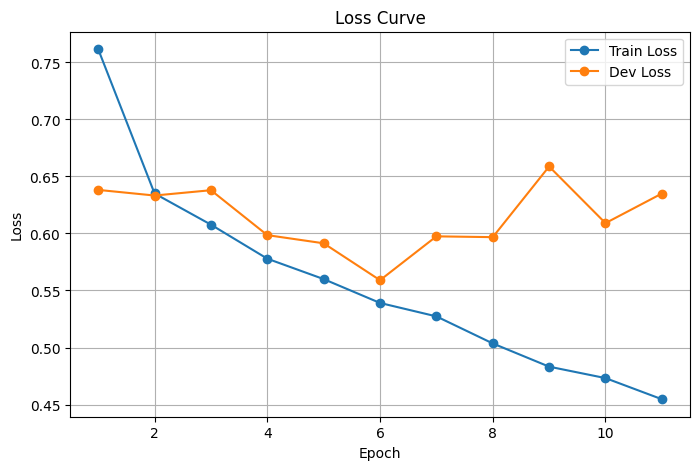

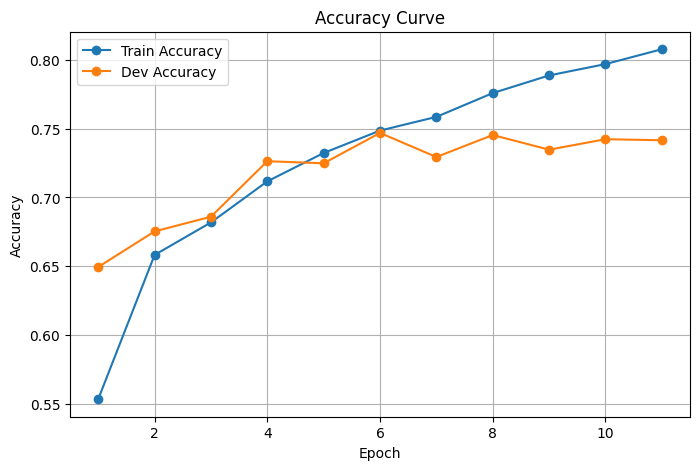

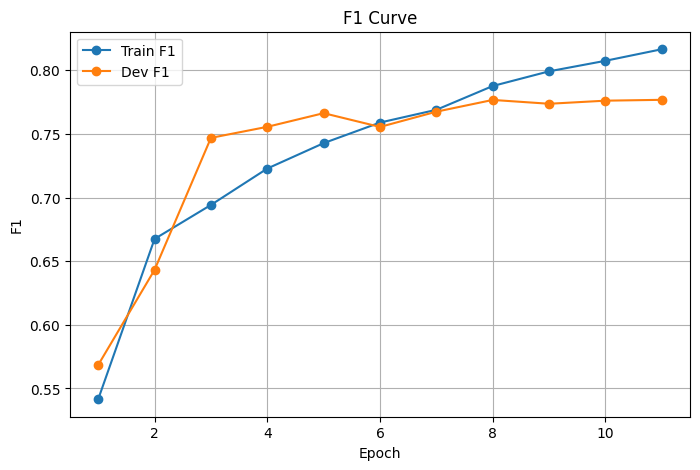

In [18]:
# ---------------------------
# 9) Curves
# ---------------------------
plt.figure(figsize=(8,5))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["epoch"], history["dev_loss"], marker="o", label="Dev Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curve")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["epoch"], history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(history["epoch"], history["dev_acc"], marker="o", label="Dev Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy Curve")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["epoch"], history["train_f1"], marker="o", label="Train F1")
plt.plot(history["epoch"], history["dev_f1"], marker="o", label="Dev F1")
plt.xlabel("Epoch"); plt.ylabel("F1"); plt.title("F1 Curve")
plt.grid(True); plt.legend(); plt.show()


⚠️ No threshold satisfied constraints. Using best-F1 threshold instead: {'accuracy': 0.743140243902439, 'precision': 0.706855791962175, 'recall': 0.8704512372634643, 'f1': 0.7801696020874103, 't': 0.4500000000000001, 'tn': 377, 'fp': 248, 'fn': 89, 'tp': 598}

DEV metrics (ARGMAX @0.5-ish): {'accuracy': 0.7454268292682927, 'precision': 0.7181705809641533, 'recall': 0.8457059679767104, 'f1': 0.7767379679144385}
DEV metrics (THRESHOLD): {'accuracy': 0.743140243902439, 'precision': 0.706855791962175, 'recall': 0.8704512372634643, 'f1': 0.7801696020874103}
DEV confusion matrix (THRESHOLD):
 [[377 248]
 [ 89 598]]


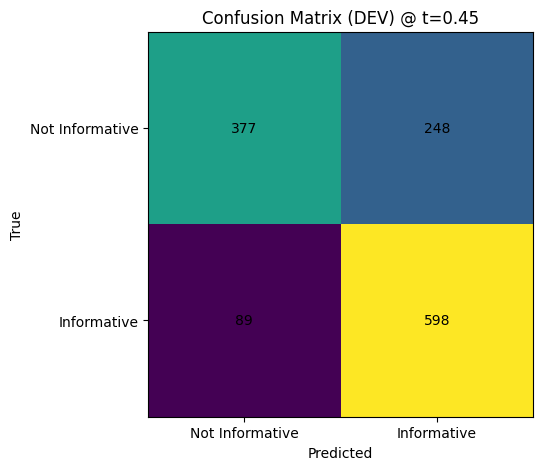


DEV classification report (THRESHOLD):
                 precision    recall  f1-score   support

Not Informative     0.8090    0.6032    0.6911       625
    Informative     0.7069    0.8705    0.7802       687

       accuracy                         0.7431      1312
      macro avg     0.7579    0.7368    0.7356      1312
   weighted avg     0.7555    0.7431    0.7377      1312



In [19]:
# ---------------------------
# 10) Threshold tuning on DEV to reduce FP (keep Recall >= 0.83 and FP < 200)
# ---------------------------
dev_loss, dev_metrics_argmax, dev_logits, dev_labels = run_eval(model, dev_loader)
dev_probs = softmax_np(dev_logits)[:, 1]

from sklearn.metrics import confusion_matrix

def eval_threshold(probs_pos: np.ndarray, y_true: np.ndarray, t: float) -> Dict[str, float]:
    y_pred = (probs_pos >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    m = metrics_from_preds(y_true, y_pred)
    m.update({"t": float(t), "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)})
    return m

REC_MIN = 0.83
FP_MAX  = 199  # below 200

cands = []
for t in np.arange(0.30, 0.91, 0.01):
    m = eval_threshold(dev_probs, dev_labels, float(t))
    if (m["recall"] >= REC_MIN) and (m["fp"] <= FP_MAX):
        cands.append(m)

if len(cands) == 0:
    # fallback: pick best F1 overall if constraints cannot be met
    sweep = [eval_threshold(dev_probs, dev_labels, float(t)) for t in np.arange(0.30, 0.91, 0.01)]
    best_t = max(sweep, key=lambda x: x["f1"])
    print("\n⚠️ No threshold satisfied constraints. Using best-F1 threshold instead:", best_t)
else:
    best_t = max(cands, key=lambda x: x["f1"])
    print("\n✅ Best threshold satisfying constraints (Recall>=0.83, FP<200):", best_t)

BEST_T = float(best_t["t"])

# DEV evaluation at BEST_T
dev_preds_t = (dev_probs >= BEST_T).astype(int)
cm = confusion_matrix(dev_labels, dev_preds_t)
print("\nDEV metrics (ARGMAX @0.5-ish):", dev_metrics_argmax)
print("DEV metrics (THRESHOLD):", metrics_from_preds(dev_labels, dev_preds_t))
print("DEV confusion matrix (THRESHOLD):\n", cm)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title(f"Confusion Matrix (DEV) @ t={BEST_T:.2f}")
plt.xticks([0,1], ["Not Informative","Informative"])
plt.yticks([0,1], ["Not Informative","Informative"])
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

print("\nDEV classification report (THRESHOLD):")
print(classification_report(dev_labels, dev_preds_t, target_names=["Not Informative","Informative"], digits=4, zero_division=0))



TEST metrics (ARGMAX @0.5-ish): {'accuracy': 0.7553353658536586, 'precision': 0.7298994974874372, 'recall': 0.8457059679767104, 'f1': 0.7835468644639245}
TEST metrics (THRESHOLD): {'accuracy': 0.7515243902439024, 'precision': 0.7177322074788902, 'recall': 0.86608442503639, 'f1': 0.7849604221635884}
TEST confusion matrix (THRESHOLD):
 [[391 234]
 [ 92 595]]


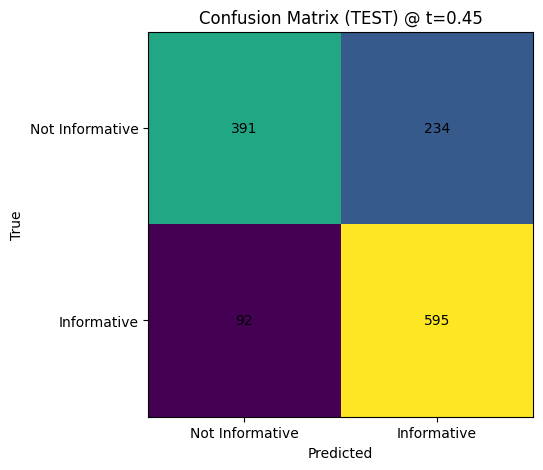


TEST classification report (THRESHOLD):
                 precision    recall  f1-score   support

Not Informative     0.8095    0.6256    0.7058       625
    Informative     0.7177    0.8661    0.7850       687

       accuracy                         0.7515      1312
      macro avg     0.7636    0.7458    0.7454      1312
   weighted avg     0.7615    0.7515    0.7472      1312



In [20]:
# ---------------------------
# 11) TEST evaluation using BEST_T (deployment-like)
# ---------------------------
test_loss, test_metrics_argmax, test_logits, test_labels = run_eval(model, test_loader)
test_probs = softmax_np(test_logits)[:, 1]
test_preds_t = (test_probs >= BEST_T).astype(int)

cm_test = confusion_matrix(test_labels, test_preds_t)
print("\nTEST metrics (ARGMAX @0.5-ish):", test_metrics_argmax)
print("TEST metrics (THRESHOLD):", metrics_from_preds(test_labels, test_preds_t))
print("TEST confusion matrix (THRESHOLD):\n", cm_test)

plt.figure(figsize=(6,5))
plt.imshow(cm_test)
plt.title(f"Confusion Matrix (TEST) @ t={BEST_T:.2f}")
plt.xticks([0,1], ["Not Informative","Informative"])
plt.yticks([0,1], ["Not Informative","Informative"])
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_test[i, j], ha="center", va="center")
plt.show()

print("\nTEST classification report (THRESHOLD):")
print(classification_report(test_labels, test_preds_t, target_names=["Not Informative","Informative"], digits=4, zero_division=0))


In [21]:
print(train_df["label_text_id"].value_counts())

label_text_id
1    3628
0    3299
Name: count, dtype: int64


In [27]:
# ---------------------------
# 12) Inference helper (uses BEST_T)
# ---------------------------
ID2LABEL = {0: "Not Informative", 1: "Informative"}

def predict_text(text: str) -> Dict[str, object]:
    model.eval()
    clean = preprocess_text(text)
    ids = torch.tensor([encode_text(clean, MAX_LEN)], dtype=torch.long).to(device)
    mask = (ids != PAD_ID).long()
    with torch.no_grad():
        logits = model(ids, mask)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    p1 = float(probs[1])
    pred = int(p1 >= BEST_T)
    return {
        "text": text,
        "clean_text": clean,
        "threshold": BEST_T,
        "pred_id": pred,
        "pred_label": ID2LABEL[pred],
        "prob_not_informative": float(probs[0]),
        "prob_informative": float(probs[1]),
    }

print("\nSanity predictions (with threshold):")
for t in [
    "rescue teams are searching for survivors after the flood",
    "today is my dog's birthday but it died 4 years ago",
    "earthquake reported near colombo, buildings shaking!",
    "No any Disaster here. Just chilling!"
]:
    out = predict_text(t)
    print("-"*60)
    print("Input:", out["text"])
    print("Clean:", out["clean_text"])
    print("Threshold:", out["threshold"])
    print("Pred:", out["pred_label"])
    print("P(Not)={:.4f} | P(Info)={:.4f}".format(out["prob_not_informative"], out["prob_informative"]))



Sanity predictions (with threshold):
------------------------------------------------------------
Input: rescue teams are searching for survivors after the flood
Clean: rescue teams are searching for survivors after the flood
Threshold: 0.4500000000000001
Pred: Informative
P(Not)=0.0214 | P(Info)=0.9786
------------------------------------------------------------
Input: today is my dog's birthday but it died 4 years ago
Clean: today dog birthday but died years ago
Threshold: 0.4500000000000001
Pred: Not Informative
P(Not)=0.8478 | P(Info)=0.1522
------------------------------------------------------------
Input: earthquake reported near colombo, buildings shaking!
Clean: earthquake reported near colombo buildings shaking !
Threshold: 0.4500000000000001
Pred: Informative
P(Not)=0.0841 | P(Info)=0.9159
------------------------------------------------------------
Input: No any Disaster here. Just chilling!
Clean: no any disaster here just chilling !
Threshold: 0.4500000000000001
Pred: No

In [28]:
# ---------------------------
# 13) Save everything for integration (including threshold)
# ---------------------------
config = {
    "vocab_size": int(sp.get_piece_size()),
    "max_len": int(MAX_LEN),
    "pad_id": int(PAD_ID),
    "bos_id": int(BOS_ID),
    "eos_id": int(EOS_ID),
    "decision_threshold": float(BEST_T),
    "model": {"d_model": 256, "n_heads": 8, "n_layers": 4, "dim_ff": 512, "dropout": 0.25},
    "tokenizer": {"type": "sentencepiece", "model_file": os.path.basename(SPM_MODEL)},
    "training": {
        "epochs_ran": int(len(history["epoch"])),
        "batch_size": int(cfg.batch_size),
        "lr": float(cfg.lr),
        "weight_decay": float(cfg.weight_decay),
        "label_smoothing": float(cfg.label_smoothing),
        "pos_weight_used": float(pos_weight),
        "warmup_ratio": float(cfg.warmup_ratio),
        "seed": int(SEED),
    }
}
with open(os.path.join(MODEL_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

label_map = {"id2label": ID2LABEL, "label2id": {"Not Informative": 0, "Informative": 1}}
with open(os.path.join(MODEL_DIR, "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=2)

print("\n✅ Saved artifacts to:", MODEL_DIR)
print("   - best_model.pt")
print("   - spm_task1a.model / spm_task1a.vocab")
print("   - config.json (includes decision_threshold)")
print("   - label_map.json")
print("\nDONE ✅")



✅ Saved artifacts to: /content/drive/MyDrive/TASK01/models/final_task1a_text_custom_transformer_MOD_1
   - best_model.pt
   - spm_task1a.model / spm_task1a.vocab
   - config.json (includes decision_threshold)
   - label_map.json

DONE ✅
